In [1]:
import rawpy
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import exifread
import os
import csv

Results for mona_lisa_Q2.ARW:
  Exposure Time: 0.025 s
  Backlight: Mean=0.449, Std=0.147
  Litho Dark: Mean=0.128, Std=0.085
  Litho Light: Mean=0.227, Std=0.156
  Transmission Dark: 0.284
  Transmission Light: 0.505
  Michelson Contrast: 0.280


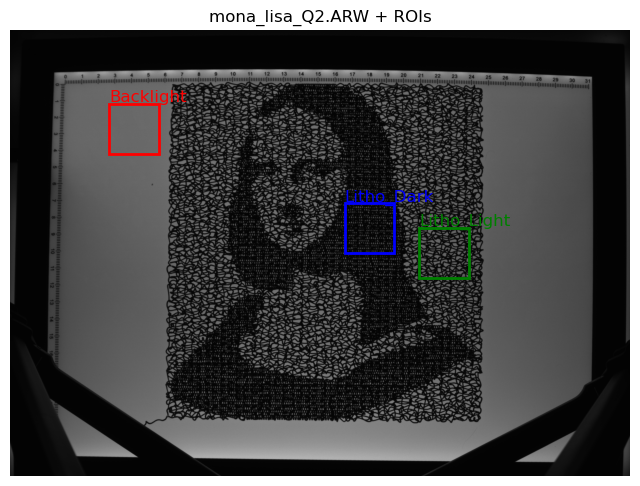

Results saved to litho_results.csv


In [ ]:
# --- USER CONFIGURATION ---
filepath = './images/mona_lisa_Q2.ARW'
output_csv = 'litho_results.csv'

# Define ROIs: (x, y, w, h), edgecolor, label
rois = {
    'Backlight': {'shape': (2100, 700, 200, 200), 'color': 'red'},
    'Litho_Dark': {'shape': (3050, 1100, 200, 200), 'color': 'blue'},
    'Litho_Light': {'shape': (3350, 1200, 200, 200), 'color': 'green'},
}

# Function to read exposure time from EXIF


def get_exposure_time(arw_path):
    with open(arw_path, 'rb') as f:
        tags = exifread.process_file(f, stop_tag="EXIF ExposureTime")
    exp = tags.get("EXIF ExposureTime")
    # exp.values[0] is a Ratio: num/den
    if exp and hasattr(exp.values[0], 'num'):
        return exp.values[0].num / exp.values[0].den
    else:
        return 1.0  # default if missing


# Prepare CSV
with open(output_csv, 'w', newline='') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow([
        'filename', 'exp_time_s',
        'mean_back', 'std_back', 'mean_dark', 'std_dark', 'mean_light', 'std_light',
        'trans_dark', 'trans_light', 'michelson_contrast'
    ])

    # Load raw and normalize
    with rawpy.imread(filepath) as raw:
        raw_img = raw.raw_image_visible.astype(np.float32)
    img = raw_img / raw_img.max()

    # Read exposure time
    t = get_exposure_time(filepath)

    # Compute ROI stats
    stats = {}
    for label, roi in rois.items():
        x, y, w, h = roi['shape']
        patch = img[y:y+h, x:x+w]
        stats[label] = {
            'mean': np.mean(patch),
            'std':  np.std(patch)
        }

    # Transmission ratios
    T_dark = stats['Litho_Dark']['mean'] / stats['Backlight']['mean']
    T_light = stats['Litho_Light']['mean'] / stats['Backlight']['mean']

    # Michelson contrast
    C = (T_light - T_dark) / (T_light + T_dark)

    # Write CSV row
    writer.writerow([
        os.path.basename(filepath), t,
        stats['Backlight']['mean'], stats['Backlight']['std'],
        stats['Litho_Dark']['mean'],  stats['Litho_Dark']['std'],
        stats['Litho_Light']['mean'], stats['Litho_Light']['std'],
        T_dark, T_light, C
    ])

    # print results to console
    print(f"Results for {os.path.basename(filepath)}:")
    print(f"  Exposure Time: {t:.3f} s")
    print(
        f"  Backlight: Mean={stats['Backlight']['mean']:.3f}, Std={stats['Backlight']['std']:.3f}")
    print(
        f"  Litho Dark: Mean={stats['Litho_Dark']['mean']:.3f}, Std={stats['Litho_Dark']['std']:.3f}")
    print(
        f"  Litho Light: Mean={stats['Litho_Light']['mean']:.3f}, Std={stats['Litho_Light']['std']:.3f}")
    print(f"  Transmission Dark: {T_dark:.3f}")
    print(f"  Transmission Light: {T_light:.3f}")
    print(f"  Michelson Contrast: {C:.3f}")

    # Overlay ROIs and show one preview
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.imshow(img, cmap='gray')
    ax.set_title(f"{os.path.basename(filepath)} + ROIs")
    ax.axis('off')
    ax.set_xlim(1700, 4200)
    ax.set_ylim(2200, 400)
    for label, roi in rois.items():
        x, y, w, h = roi['shape']
        rect = mpatches.Rectangle((x, y), w, h, fill=False,
                                  edgecolor=roi['color'], linewidth=2)
        ax.add_patch(rect)
        ax.text(x, y-10, label, color=roi['color'], fontsize=12)
    plt.show()

# Final message
print(f"Results saved to {output_csv}")